---
title: "Clustering QC"
author: "Mary Piper, Lorena Pantano, Meeta Mistry, Radhika Khetani, Jihe Liu"
date: Monday, July 20th, 2020
---

Approximate time: 90 minutes

## Learning Objectives:

* Evaluate whether clustering artifacts are present 
* Determine the quality of clustering with PCA and UMAP plots, and decide when to re-cluster
* Assess known cell type markers to hypothesize cell type identities of clusters

# Single-cell RNA-seq clustering analysis


Now that we have performed the integration, we want to know the different cell types present within our population of cells. 

<p align="center">
<img src="../img/sc_workflow_2022.jpg" width="630">
</p>

***

_**Goals:**_ 
 
 - _To **determine whether clusters represent true cell types or cluster due to biological or technical variation**, such as clusters of cells in the S phase of the cell cycle, clusters of specific batches, or cells with high mitochondrial content._
 - _To use known cell type marker genes to **determine the identities of the clusters**._

_**Challenges:**_
 - _**Identifying the cell types** of each cluster_
 - _Maintaining patience as this can be a highly iterative process between clustering and marker identification (sometimes even going back to the QC filtering or normalization)_

_**Recommendations:**_
 
 - _Have a good idea of your expectations for the **cell types to be present** and a handful of marker genes for these cell types. Know whether you expect cell types of low complexity or higher mitochondrial content AND whether the cells are differentiating_
 - _Identify any junk clusters for removal. Possible junk clusters could include those with high **mitochondrial content** and low UMIs/genes_
 - _If **not detecting all cell types as separate clusters**, try changing the UMAP resolution first, and if this doesn't work, then can alter the number of PCs used for clustering, the number of variable genes used, or subset the dataset to clusters of interest and re-cluster_

***

In [1]:
# Single-cell RNA-seq - clustering QC

import scanpy as sc
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata_clust = sc.read_h5ad("../results/10_clusters.h5ad")
adata_clust

AnnData object with n_obs × n_vars = 29629 × 14167
    obs: 'n_genes', 'sample', 'n_genes_by_counts', 'total_counts', 'log10GenesPerUMI', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'mito_ratio', 'S_score', 'G2M_score', 'phase', 'mitoFr', '_scvi_batch', '_scvi_labels', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.4'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mito', 'log1p_mean_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'id_hvg', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_1.0

## Exploration of quality control metrics

To determine whether our clusters might be due to artifacts such as cell cycle phase or mitochondrial expression, it can be useful to explore these metrics visually to see if any clusters exhibit enrichment or are different from the other clusters. However, if enrichment or differences are observed for particular clusters it may not be worrisome if it can be explained by the cell type. 

To explore and visualize the various quality metrics, we will use the versatile `pl.embedding` function of scanpy.

### Segregation of clusters by sample

We can start by exploring the distribution of cells per cluster in each sample:

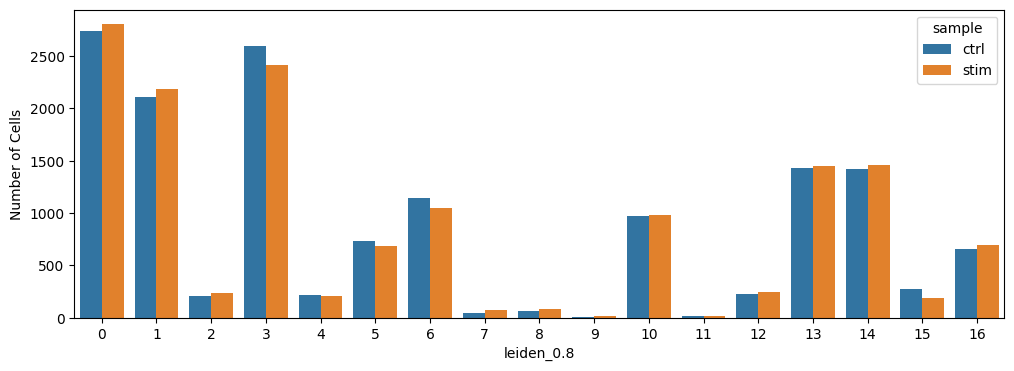

In [3]:
plt.figure(figsize=(12,4))
sns.countplot(data=adata_clust.obs, x='leiden_0.8', hue='sample')
plt.ylabel('Number of Cells')
plt.show()

We can visualize the cells per cluster for each sample using the UMAP:

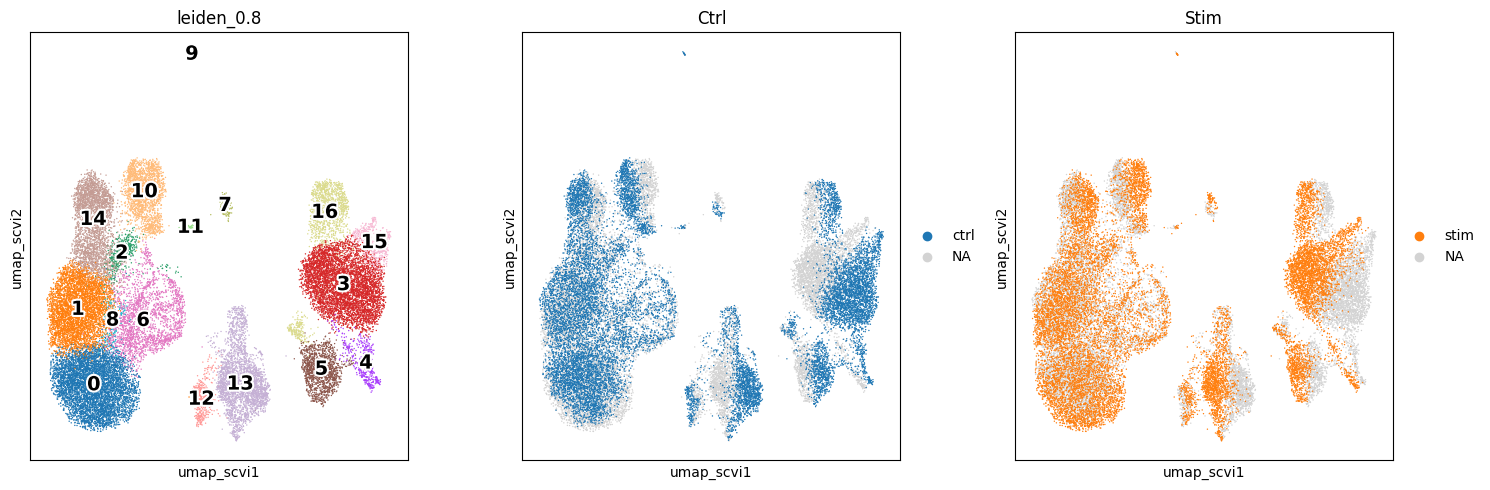

In [26]:
# Create plot with the correct dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each phase
sc.pl.embedding(adata_clust, color="leiden_0.8", ax=axes[0], 
                show=False, basis="umap_scvi",
                legend_loc='on data', legend_fontsize=14,
                legend_fontoutline=3)
sc.pl.embedding(adata_clust, color="sample", groups="ctrl", ax=axes[1], 
          show=False, title="Ctrl", basis="umap_scvi")
sc.pl.embedding(adata_clust, color="sample", groups="stim", ax=axes[2], 
          show=False, title="Stim", basis="umap_scvi")

plt.tight_layout()
plt.show()

Additionally, we can supply the metadata dataframe from our seurat object into ggplot to create more visuals. Looking at a UMAP is a great way to get a first pass look at your dataset, but we encourage you to look at your data in multiple different ways. For example, looking at the proportion of cells from a sample in each cluster.


In [14]:
# Prepare proportions table
prop_df = (
    adata_clust.obs.groupby(['leiden_0.8', 'sample'], observed=True)
      .size()
      .unstack(fill_value=0)
      .div(adata_clust.obs.groupby('leiden_0.8', observed=True).size(), axis=0)
)
prop_df.head()

sample,ctrl,stim
leiden_0.8,,
0,0.494045,0.505955
1,0.490452,0.509548
2,0.468326,0.531674
3,0.517358,0.482642
4,0.511905,0.488095


Now that we have `prop_df` with the proportion scores we can plot this as a proportional barplot.

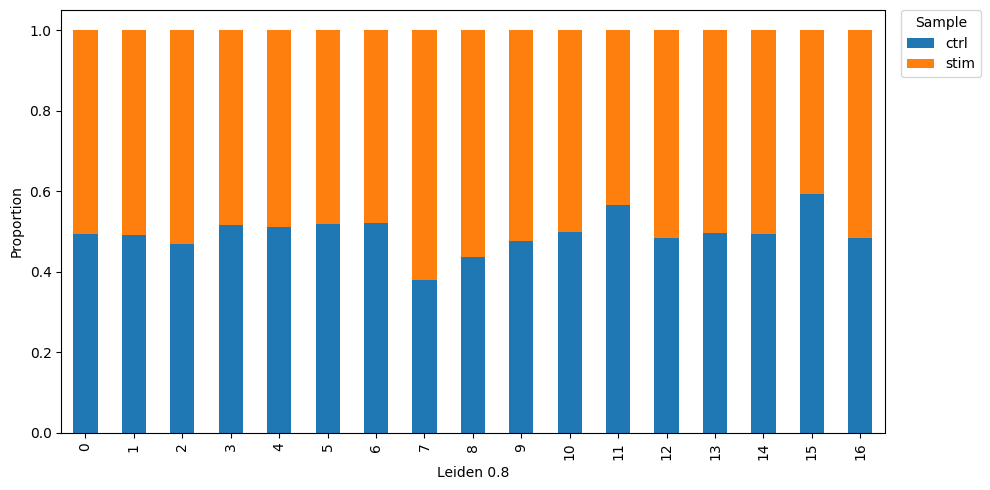

In [17]:
# Plot
prop_df.plot(kind='bar',
                stacked=True,
                figsize=(10, 5))
plt.ylabel('Proportion')
plt.xlabel('Leiden 0.8')

# Move legend to the right
plt.legend(title='Sample', bbox_to_anchor=(1.02, 1), 
           loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

Generally, we expect to see the majority of the cell type clusters to be present in all conditions; however, depending on the experiment we might expect to see some condition-specific cell types present. These clusters look pretty similar between conditions, which is good since we expected similar cell types to be present in both control and stimulated conditions.

### Segregation of clusters by cell cycle phase

Next, we can explore whether the **cells cluster by the different cell cycle phases**. We did not regress out variation due to cell cycle phase when we performed the SCTransform normalization and regression of uninteresting sources of variation. If our cell clusters showed large differences in cell cycle expression, this would be an indication we would want to re-run the SCTransform and add the `S.Score` and `G2M.Score` to our variables to regress, then re-run the rest of the steps.



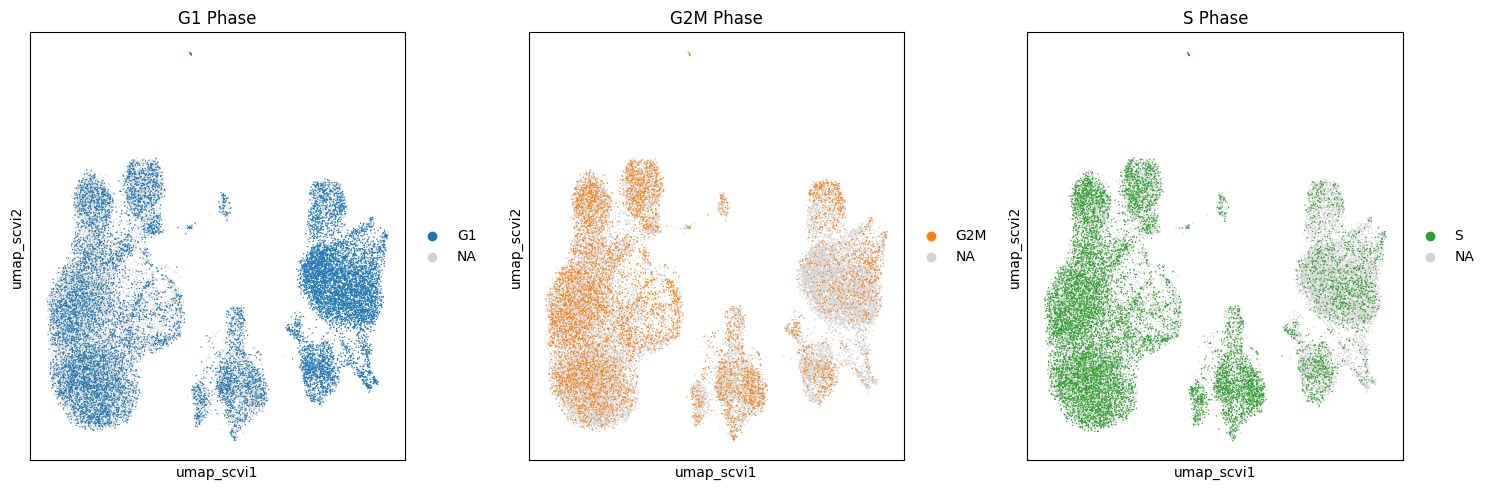

In [28]:
# Create plot with the correct dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each phase
sc.pl.embedding(adata_clust, color=["phase"], groups=["G1"], ax=axes[0], 
          show=False, title="G1 Phase", basis="umap_scvi")
sc.pl.embedding(adata_clust, color=["phase"], groups=["G2M"], ax=axes[1], 
          show=False, title="G2M Phase", basis="umap_scvi")
sc.pl.embedding(adata_clust, color=["phase"], groups=["S"], ax=axes[2], 
          show=False, title="S Phase", basis="umap_scvi")

plt.tight_layout()
plt.show()

We do not see much clustering by cell cycle score, so we can proceed with the QC.

### Segregation of clusters by various sources of uninteresting variation

Next we will explore additional metrics, such as the number of UMIs and genes per cell, S-phase and G2M-phase markers, and mitochondrial gene expression by UMAP. Looking at the individual S and G2M scores can give us additional information to checking the phase as we did previously.


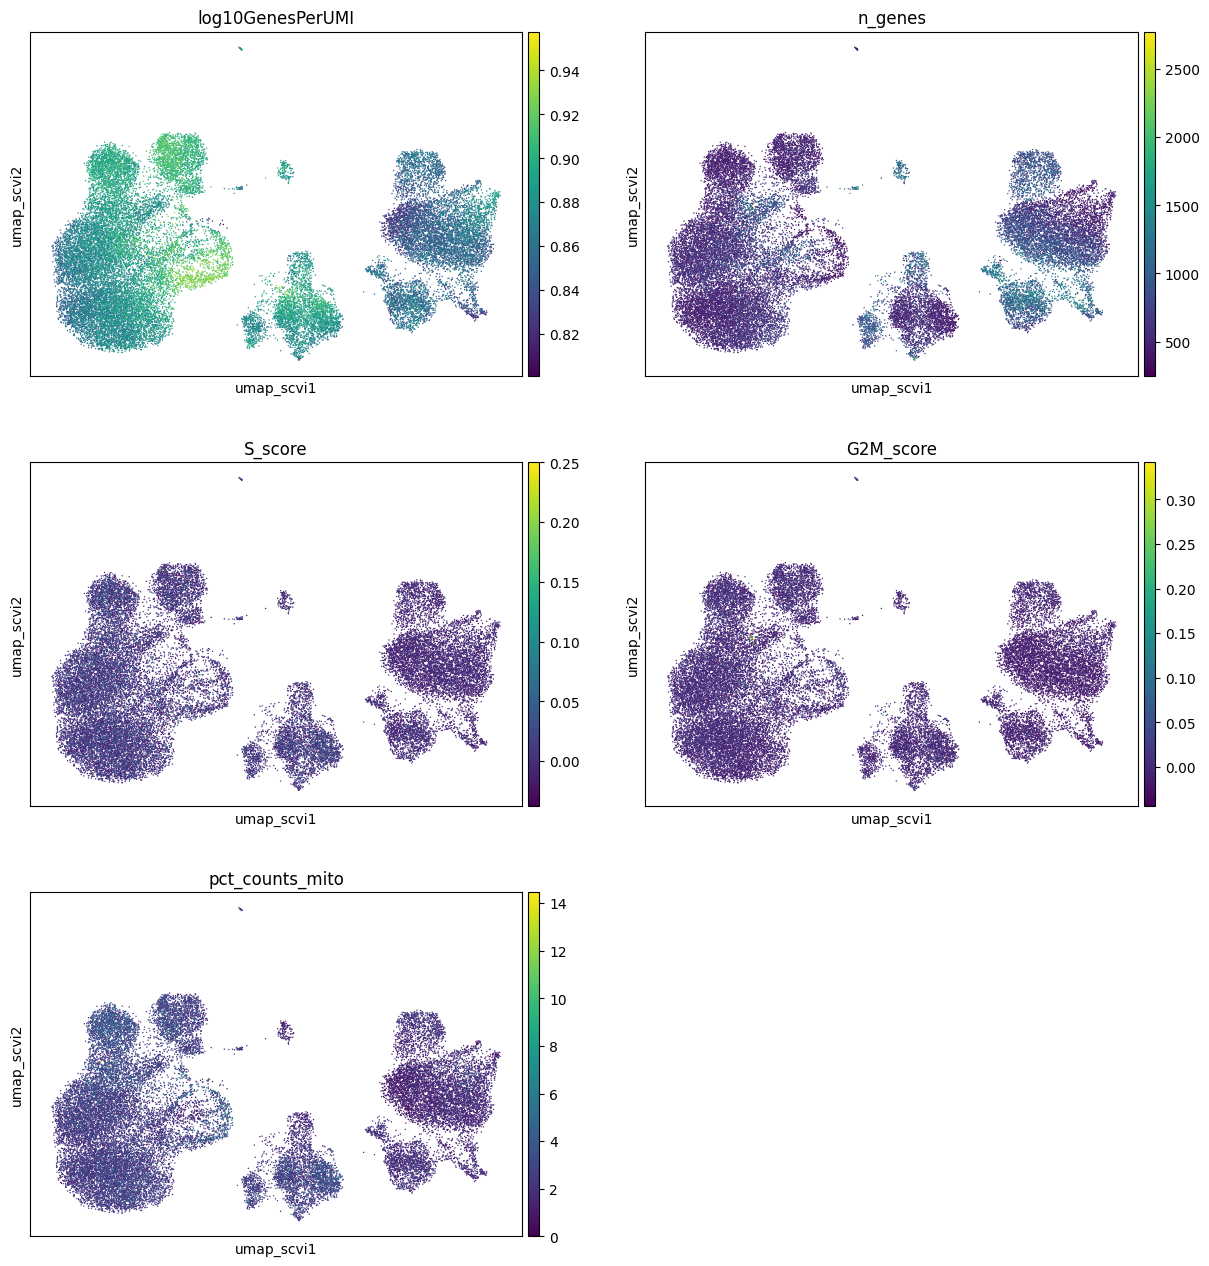

In [31]:
cols = ["log10GenesPerUMI", "n_genes", "S_score", 
        "G2M_score", "pct_counts_mito"]
sc.pl.embedding(adata_clust, color=cols, basis="umap_scvi", ncols=2)

::: callout-note
The `order` argument will plot the positive cells above the negative cells, while the `min.cutoff` argument will determine the threshold for shading. A `min.cutoff` of `q10` translates to the 10% of cells with the lowest expression of the gene will not exhibit any purple shading (completely gray).
:::

The metrics seem to be relatively even across the clusters, with the exception of `nGene` exhibiting slightly higher values in clusters to the left of the plot. This can be more clearly seen when we look at the distribution as a boxplot. We can keep an eye on these clusters to see whether the cell types may explain the increase.

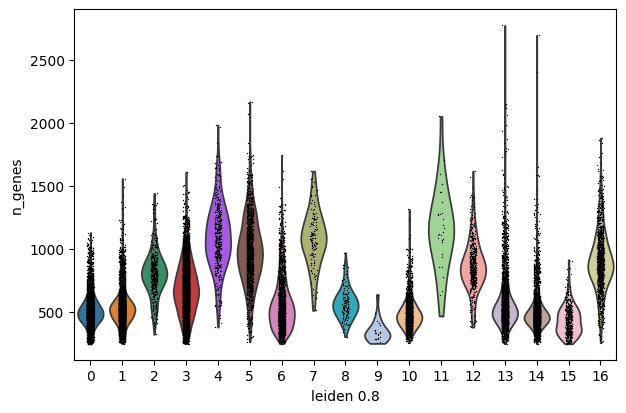

In [34]:
sc.pl.violin(adata_clust, groupby="leiden_0.8", keys="n_genes")

If we see differences corresponding to any of these metrics at this point in time, then we will often note them and then decide after identifying the cell type identities whether to take any further action.

### Exploration of the PCs driving the different clusters

We can also explore how well our clusters separate by the different PCs; we hope that the defined PCs separate the cell types well. To visualize this information, we need to extract the UMAP coordinate information for the cells along with their corresponding scores for each of the PCs to view by UMAP. 

In the UMAP plots below, the cells are colored by their PC score for each respective principal component. 

Let's take a quick look at the top 16 PCs:

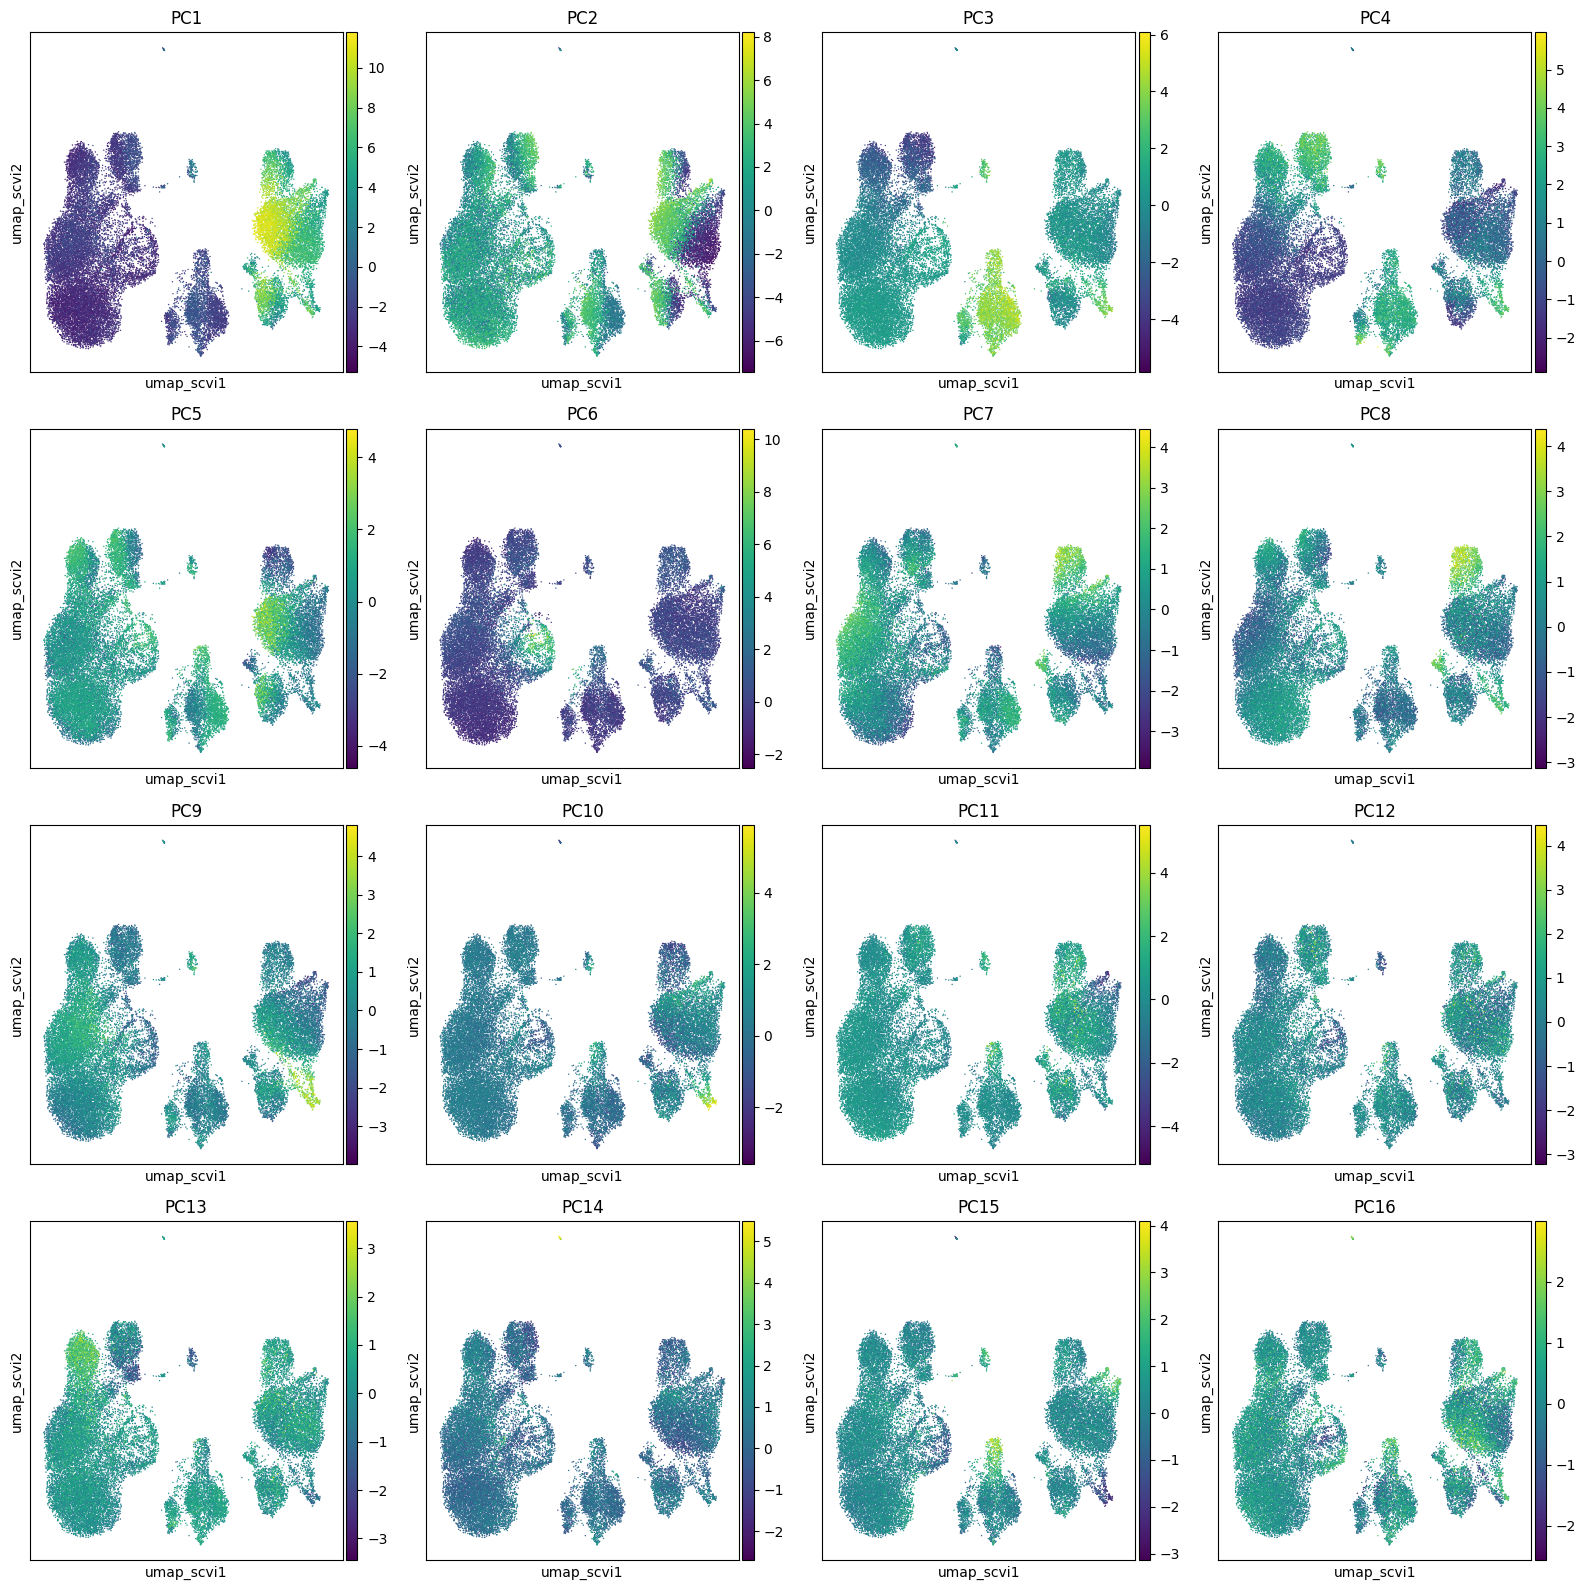

In [43]:
n_pcs = 16

# Add PC score columns to adata.obs
for pc_ix in range(n_pcs):
    adata_clust.obs[f'PC{pc_ix+1}_score'] = adata_clust.obsm['X_pca'][:, pc_ix]

# Create 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for ix in range(n_pcs):
    row, col = divmod(ix, 4)
    ax = axes[row, col]
    sc.pl.embedding(
        adata_clust,
        color=f'PC{ix+1}_score',
        ax=ax,
        show=False,
        cmap='viridis',
        title=f"PC{ix+1}",
        basis="umap_scvi")

plt.tight_layout()
plt.show()

We can see how the clusters are represented by the different PCs. For instance, the genes driving `PC_2` exhibit higher expression in clusters 8 and 12. We could look back at our genes driving this PC to get an idea of what the cell types might be:


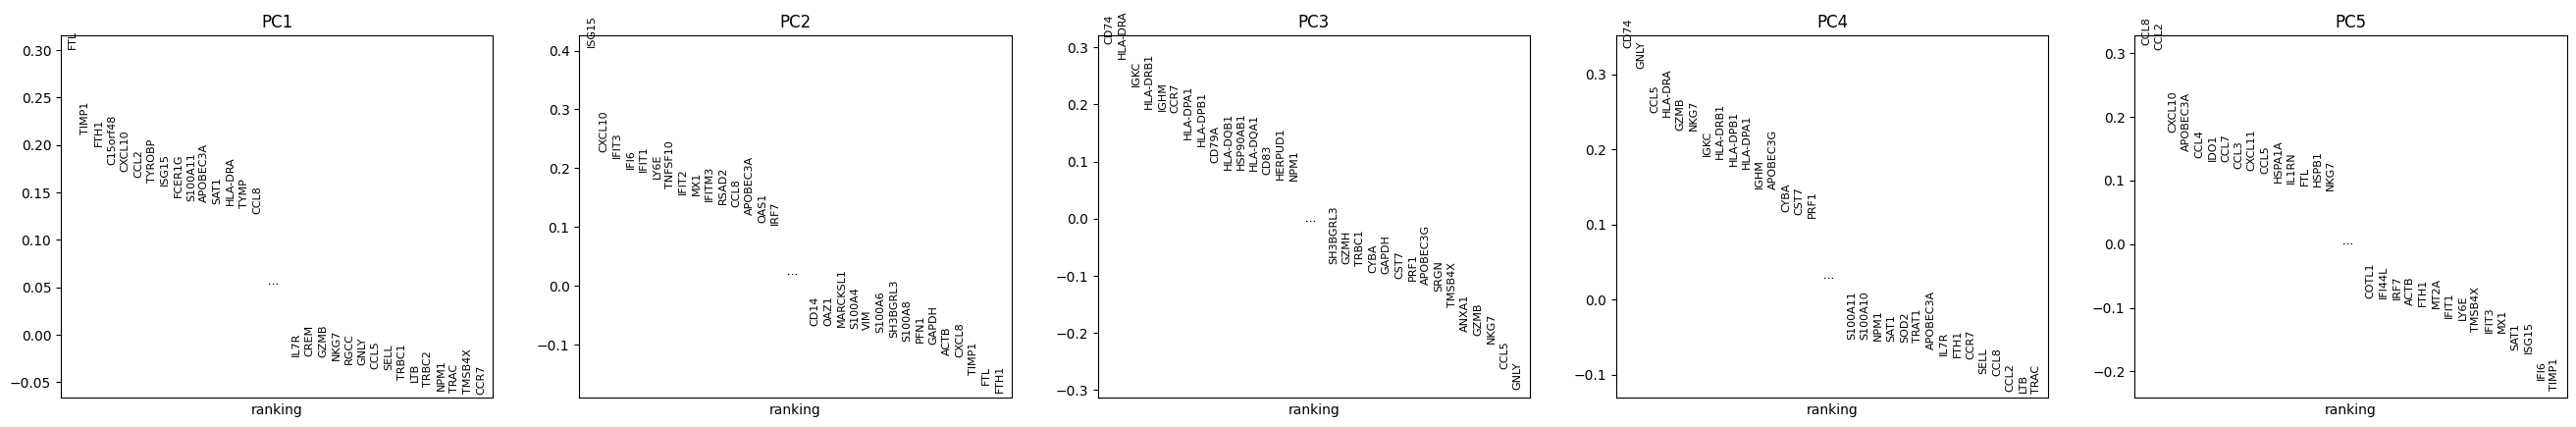

In [47]:
sc.pl.pca_loadings(adata_clust, components = '1,2,3,4,5')

With the GNLY and NKG7 genes as positive markers of `PC_2`, we can hypothesize that clusters 8 and 12 correspond to NK cells. This just hints at what the clusters identity could be, with the identities of the clusters being determined through a combination of the PCs. 

To truly determine the identity of the clusters and whether the `resolution` is appropriate, it is helpful to explore a handful of known gene markers for the cell types expected. 

## Exploring known cell type markers

With the cells clustered, we can explore the cell type identities by looking for known markers. The UMAP plot with clusters marked is shown, followed by the different cell types expected.

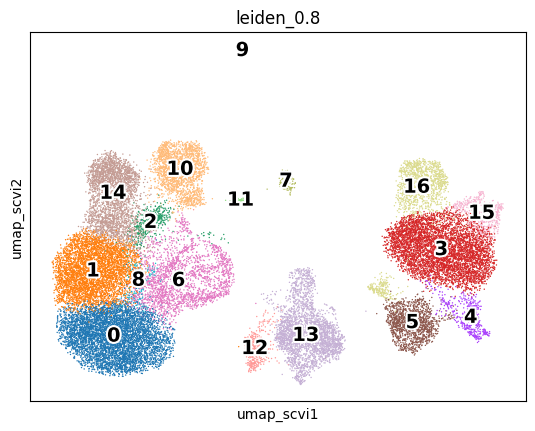

In [51]:
sc.pl.embedding(adata_clust, color="leiden_0.8",
                basis="umap_scvi", legend_loc='on data', 
                legend_fontsize=14, legend_fontoutline=3)

| Cell Type | Marker |
|:---:|:---:|
| CD14+ monocytes | CD14, LYZ | 
| FCGR3A+ monocytes | FCGR3A, MS4A7 |
| Conventional dendritic cells | FCER1A, CST3 |
| Plasmacytoid dendritic cells | IL3RA, GZMB, SERPINF1, ITM2C |
| B cells | CD79A, MS4A1 |
| T cells | CD3D |
| CD4+ T cells | CD3D, IL7R, CCR7 |
| CD8+ T cells| CD3D, CD8A |
| NK cells | GNLY, NKG7 |
| Megakaryocytes | PPBP |
| Erythrocytes | HBB, HBA2 |

It is easy to visualize a handful of genes using the gene IDs stored in the Seurat object. We can easily explore the expression of known gene markers on top of our UMAP visualizations. Let's go through and determine the identities of the clusters. 

Depending on our markers of interest, they could be positive or negative markers for a particular cell type. The combined expression of our chosen handful of markers should give us an idea on whether a cluster corresponds to that particular cell type. 

For the markers used here, we are looking for positive markers and consistency of expression of the markers across the clusters. For example, if there are two markers for a cell type and only one of them is expressed in a cluster - then we cannot reliably assign that cluster to the cell type.

**CD14+ monocyte markers**

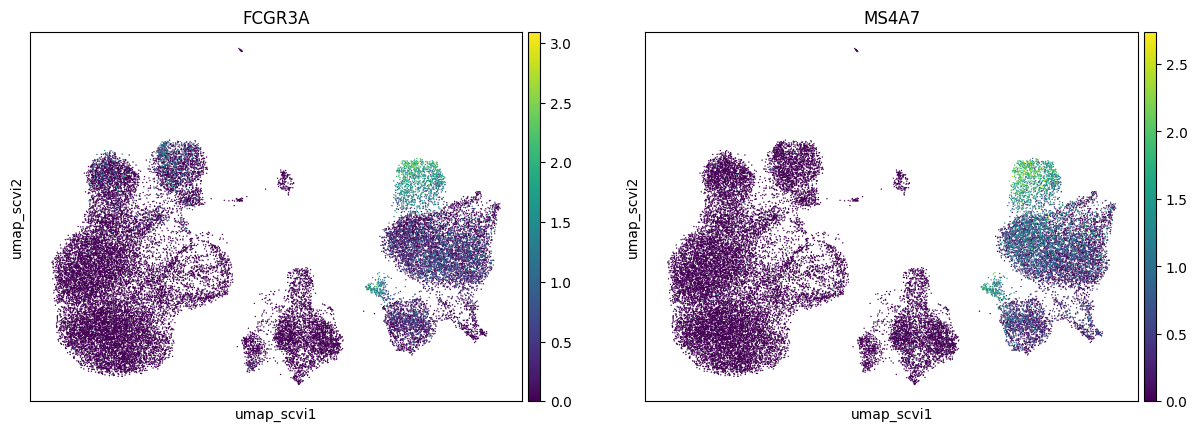

In [56]:
sc.pl.embedding(adata_clust, color=["FCGR3A", "MS4A7"],
                basis="umap_scvi", legend_loc='on data')

FCGR3A+ monocytes markers distinctly highlight cluster 10, although we do see some decent expression in clusters 1 and 3 We would like to see additional markers for FCGR3A+ cells show up when we perform the marker identification.

**Macrophages**


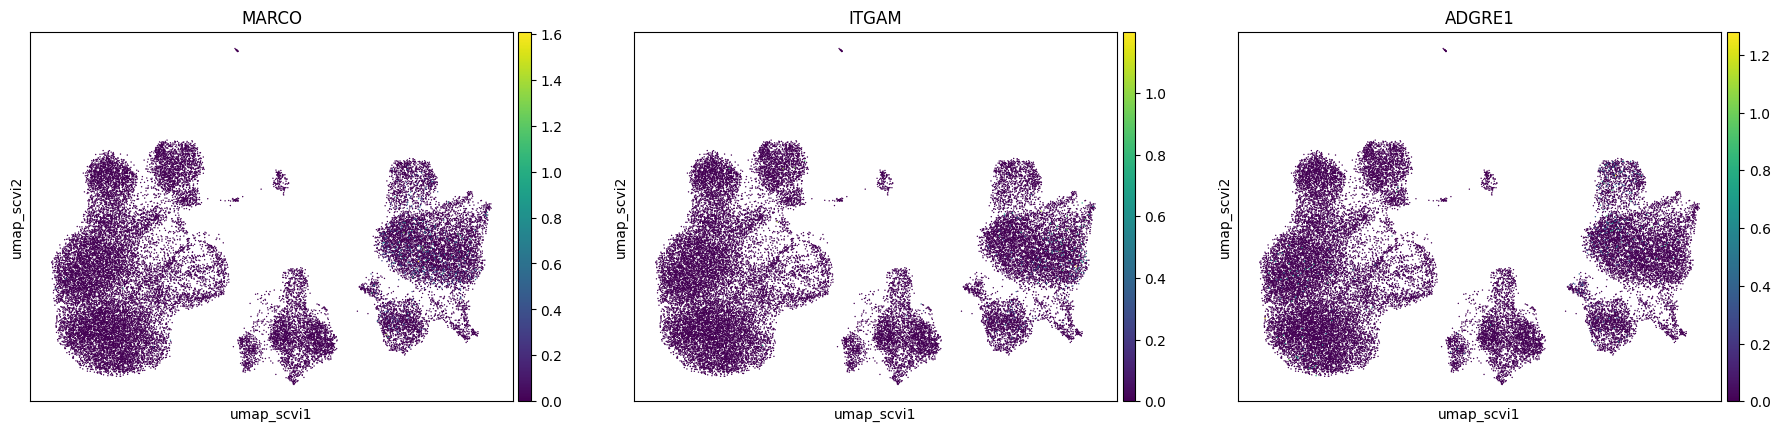

In [55]:
sc.pl.embedding(adata_clust, color=["MARCO", "ITGAM", "ADGRE1"],
                basis="umap_scvi")

We don't see much overlap of our markers, so no clusters appear to correspond to macrophages; perhaps cell culture conditions negatively selected for macrophages (more highly adherent).

**Conventional dendritic cell markers**


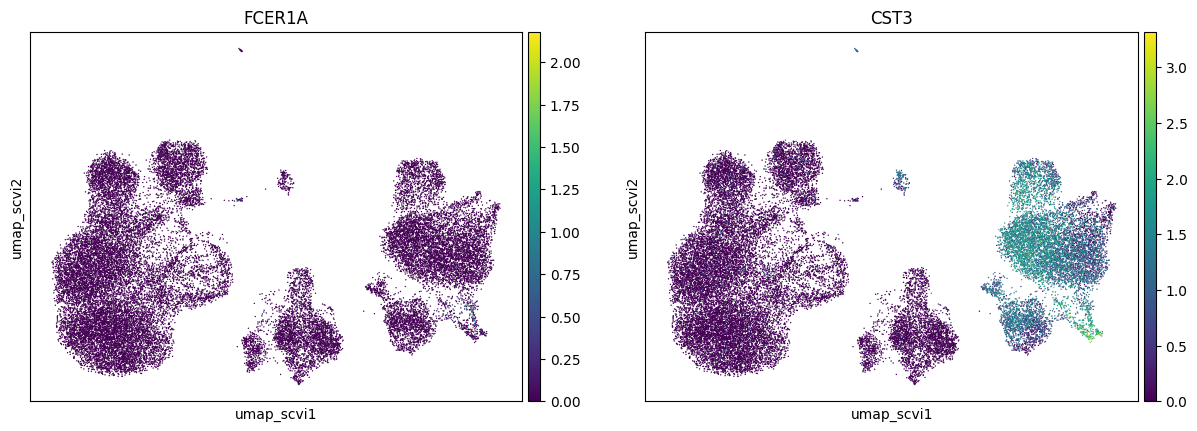

In [57]:
sc.pl.embedding(adata_clust, color=["FCER1A", "CST3"],
                basis="umap_scvi")

The markers corresponding to conventional dendritic cells identify cluster 14 (both markers consistently show expression).

**Plasmacytoid dendritic cell markers**


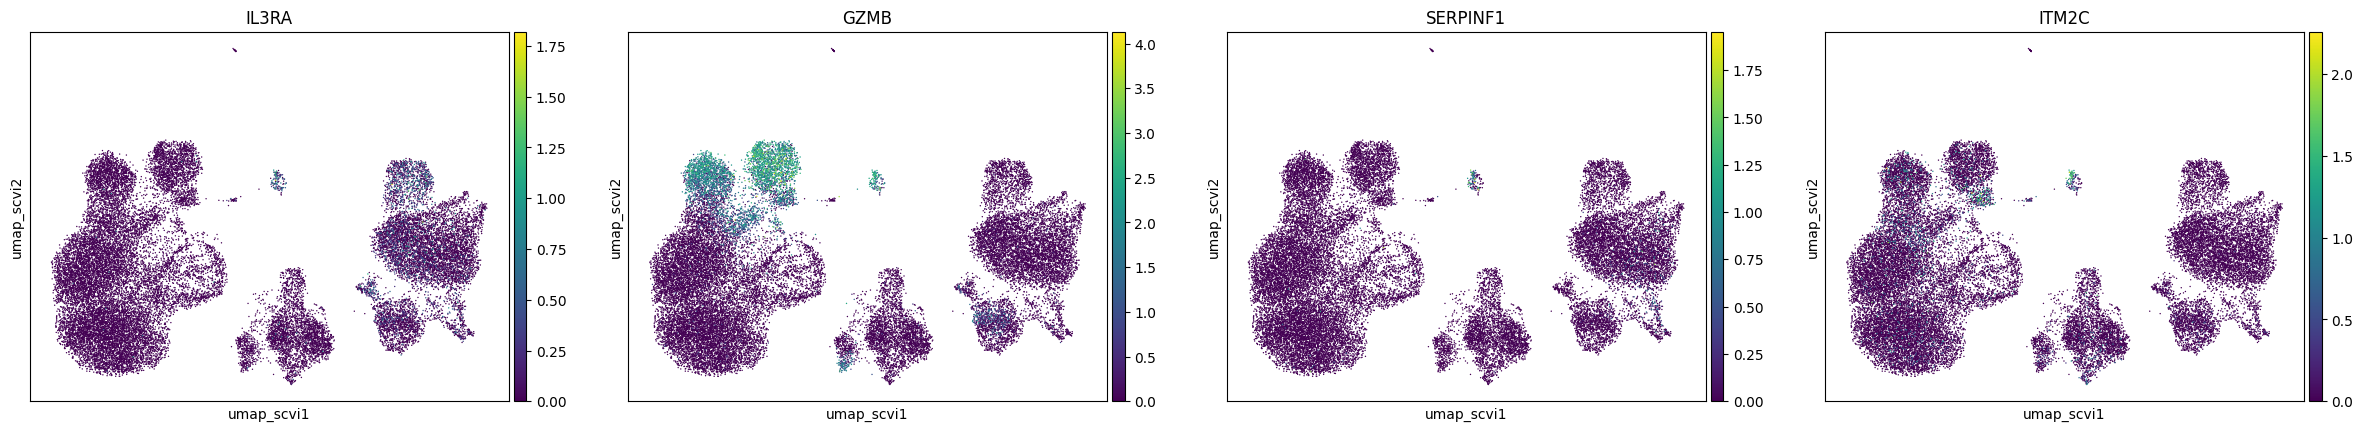

In [58]:
sc.pl.embedding(adata_clust, color=["IL3RA", "GZMB", "SERPINF1", "ITM2C"],
                basis="umap_scvi")

Plasmacytoid dendritic cells represent cluster 16. While there are a lot of differences in the expression of these markers, we see cluster 16 (though small) is consistently strongly expressed.

***

Scanpy also has a built in visualization tool which allows us to view the average expression of genes across clusters called `DotPlot()`. This function additionally shows us how many cells within the cluster have expression of one gene. As input, we supply a dictionary of genes, where we label the celltype associated as the key for labeling purposes.

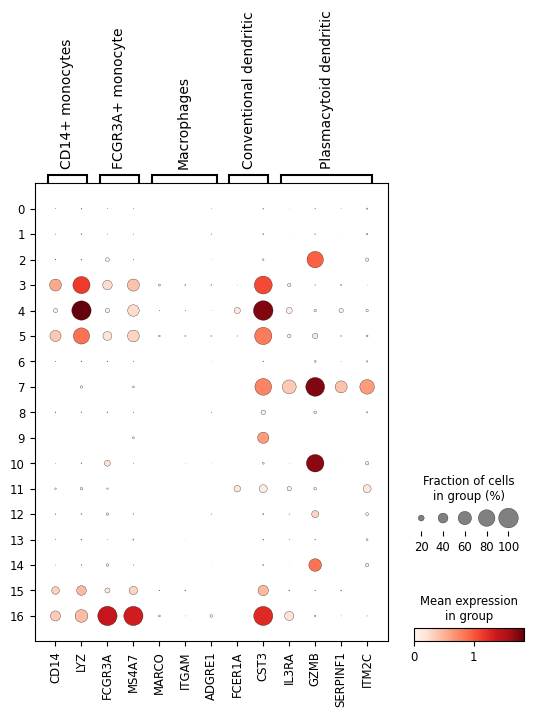

In [60]:
markers = {
    "CD14+ monocytes": ["CD14", "LYZ"],
    "FCGR3A+ monocyte": ["FCGR3A", "MS4A7"],
    "Macrophages": ["MARCO", "ITGAM", "ADGRE1"],
    "Conventional dendritic": ["FCER1A", "CST3"],
    "Plasmacytoid dendritic": ["IL3RA", "GZMB", "SERPINF1", "ITM2C"]}

sc.pl.dotplot(adata_clust, markers, 
              groupby='leiden_0.8')


::: callout-tip
# [**Exercise 1**](11_clustering_quality_control-Answer_key.qmd#exercise-1)
Hypothesize the clusters corresponding to each of the different clusters in the table:

| Cell Type | Clusters |
|:---:|:---:|
| CD14+ monocytes | 1, 3 | 
| FCGR3A+ monocytes | 10 |
| Conventional dendritic cells | 14 |
| Plasmacytoid dendritic cells | 16 |
| Marcrophages | - |
| B cells | ? |
| T cells | ? |
| CD4+ T cells | ? |
| CD8+ T cells| ? |
| NK cells | ? |
| Megakaryocytes | ? |
| Erythrocytes | ? |
| Unknown | ? |
:::

***

::: callout-note
If any cluster appears to contain two separate cell types, it's helpful to increase our clustering resolution to properly subset the clusters. Alternatively, if we still can't separate out the clusters using increased resolution, then it's possible that we had used too few principal components such that we are just not separating out these cell types of interest. To inform our choice of PCs, we could look at our PC gene expression overlapping the UMAP plots and determine whether our cell populations are separating by the PCs included.
:::

Now we have a decent idea as to the cell types corresponding to the majority of the clusters, but some questions remain:

1. *T cell markers appear to be highly expressed in may clusters. How can we differentiate and subset the larger group into smaller subset of cells?*
2. *Do the clusters corresponding to the same cell types have biologically meaningful differences? Are there subpopulations of these cell types?*
3. *Can we acquire higher confidence in these cell type identities by identifying other marker genes for these clusters?*

Marker identification analysis can help us address all of these questions!! 

The next step will be to perform marker identification analysis, which will output the genes that significantly differ in expression between clusters. Using these genes we can determine or improve confidence in the identities of the clusters/subclusters.